# Drivers Correlation ERA5 Figure

In [1]:
%reload_ext autoreload
%autoreload 2
import os
import sys
import matplotlib.pyplot as plt
import pickle
# Add the folder to the Python path

os.chdir("../")
# change working directory to project's root path
print(os.getcwd())

folder_path = os.path.abspath("functions/") #INPUT_PATH)#'path_to_your_folder')  # Replace with the actual folder path
sys.path.insert(0, folder_path)

c:\Users\marti\Desktop\data\hw_extra


In [2]:
import pandas as pd
import seaborn as sns

In [3]:
with open("data/03_primary/drivers/era5_dict.pickle", 'rb') as handle:
    era5_v2 = pickle.load(handle)

In [4]:
hws_chile = pd.read_csv("data/local_data/monthly/hws_chile_new_agg.csv")

hws_chile["time"] = pd.to_datetime(hws_chile["Unnamed: 0"],format='%Y-%m')
hws_chile.set_index('time', inplace=True)
hws_chile.drop(columns="Unnamed: 0", inplace=True)
# hws_chile = hws_chile[["hwn", "hwf", "hwd", "hwm", "hwa", "hwmeani"]]
hws_chile

,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
time,,,,,,,,,
1971-01-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-02-01,0.2,0.7,0.7,0.447148,0.807169,0.7,1.508644,1.508644,1.508644
1971-03-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-04-01,0.2,0.6,0.6,0.637038,0.982249,0.6,1.911113,1.911113,1.911113
1971-05-01,0.1,0.3,0.3,0.555671,0.901254,0.3,1.667013,1.667013,1.667013
...,...,...,...,...,...,...,...,...,...
2024-08-01,0.4,1.3,1.3,0.759857,1.294393,1.3,2.501609,2.501609,2.501609
2024-09-01,0.2,0.6,0.6,0.367076,0.617588,0.6,1.101228,1.101228,1.101228
2024-10-01,0.4,1.2,0.9,0.853280,1.349775,0.9,3.552305,2.792164,2.559840


In [7]:
era5_df = pd.concat((era5_v2["ERA5"],hws_chile),axis=1)
era5_df["adv_blob"]

time
1970-01-01    4.373896
1970-02-01    1.410319
1970-03-01   -0.125989
1970-04-01    2.870172
1970-05-01   -0.669026
                ...   
2024-08-01    0.409726
2024-09-01    0.408446
2024-10-01   -1.550170
2024-11-01    0.212082
2024-12-01   -1.077120
Freq: MS, Name: adv_blob, Length: 660, dtype: float32

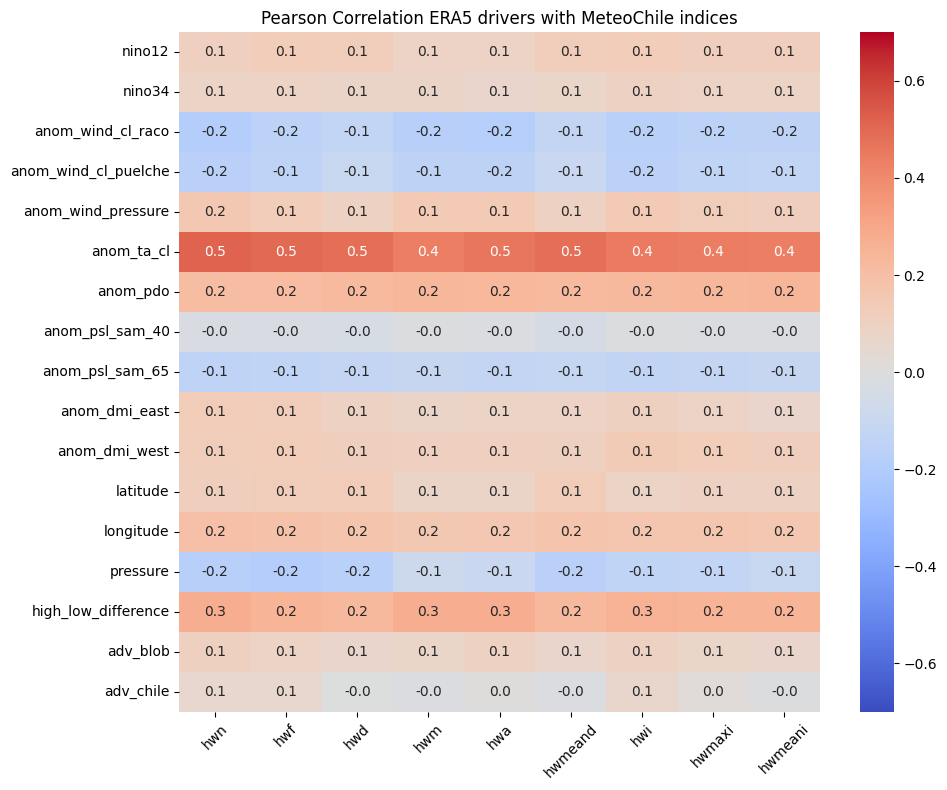

In [6]:
fig, ax = plt.subplots(figsize=(10,8))
# display(
df = era5_df.corr()[-9:].T[:-9]
sns.heatmap(df, annot=True, cmap='coolwarm', ax=ax, vmin=-0.7, vmax=0.7, cbar=True,  fmt=".1f")
    # .style.set_caption("Correlation for ERA5")
    # .background_gradient(cmap="coolwarm")
    # .format("{:.2f}")
    # )
ax.tick_params(axis='x', labelrotation=45)
ax.set_title(f"Pearson Correlation ERA5 drivers with MeteoChile indices")
fig.tight_layout()
# display(
#     era5_df
#     .corr()[-9:].T[:-9]
#     .style.set_caption("Correlation for ERA5")
#     .background_gradient(cmap="coolwarm")
#     .format("{:.2f}")
#     )

C:\Users\marti\AppData\Local\Temp\ipykernel_16576\3779435731.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0,0,0.9,1))


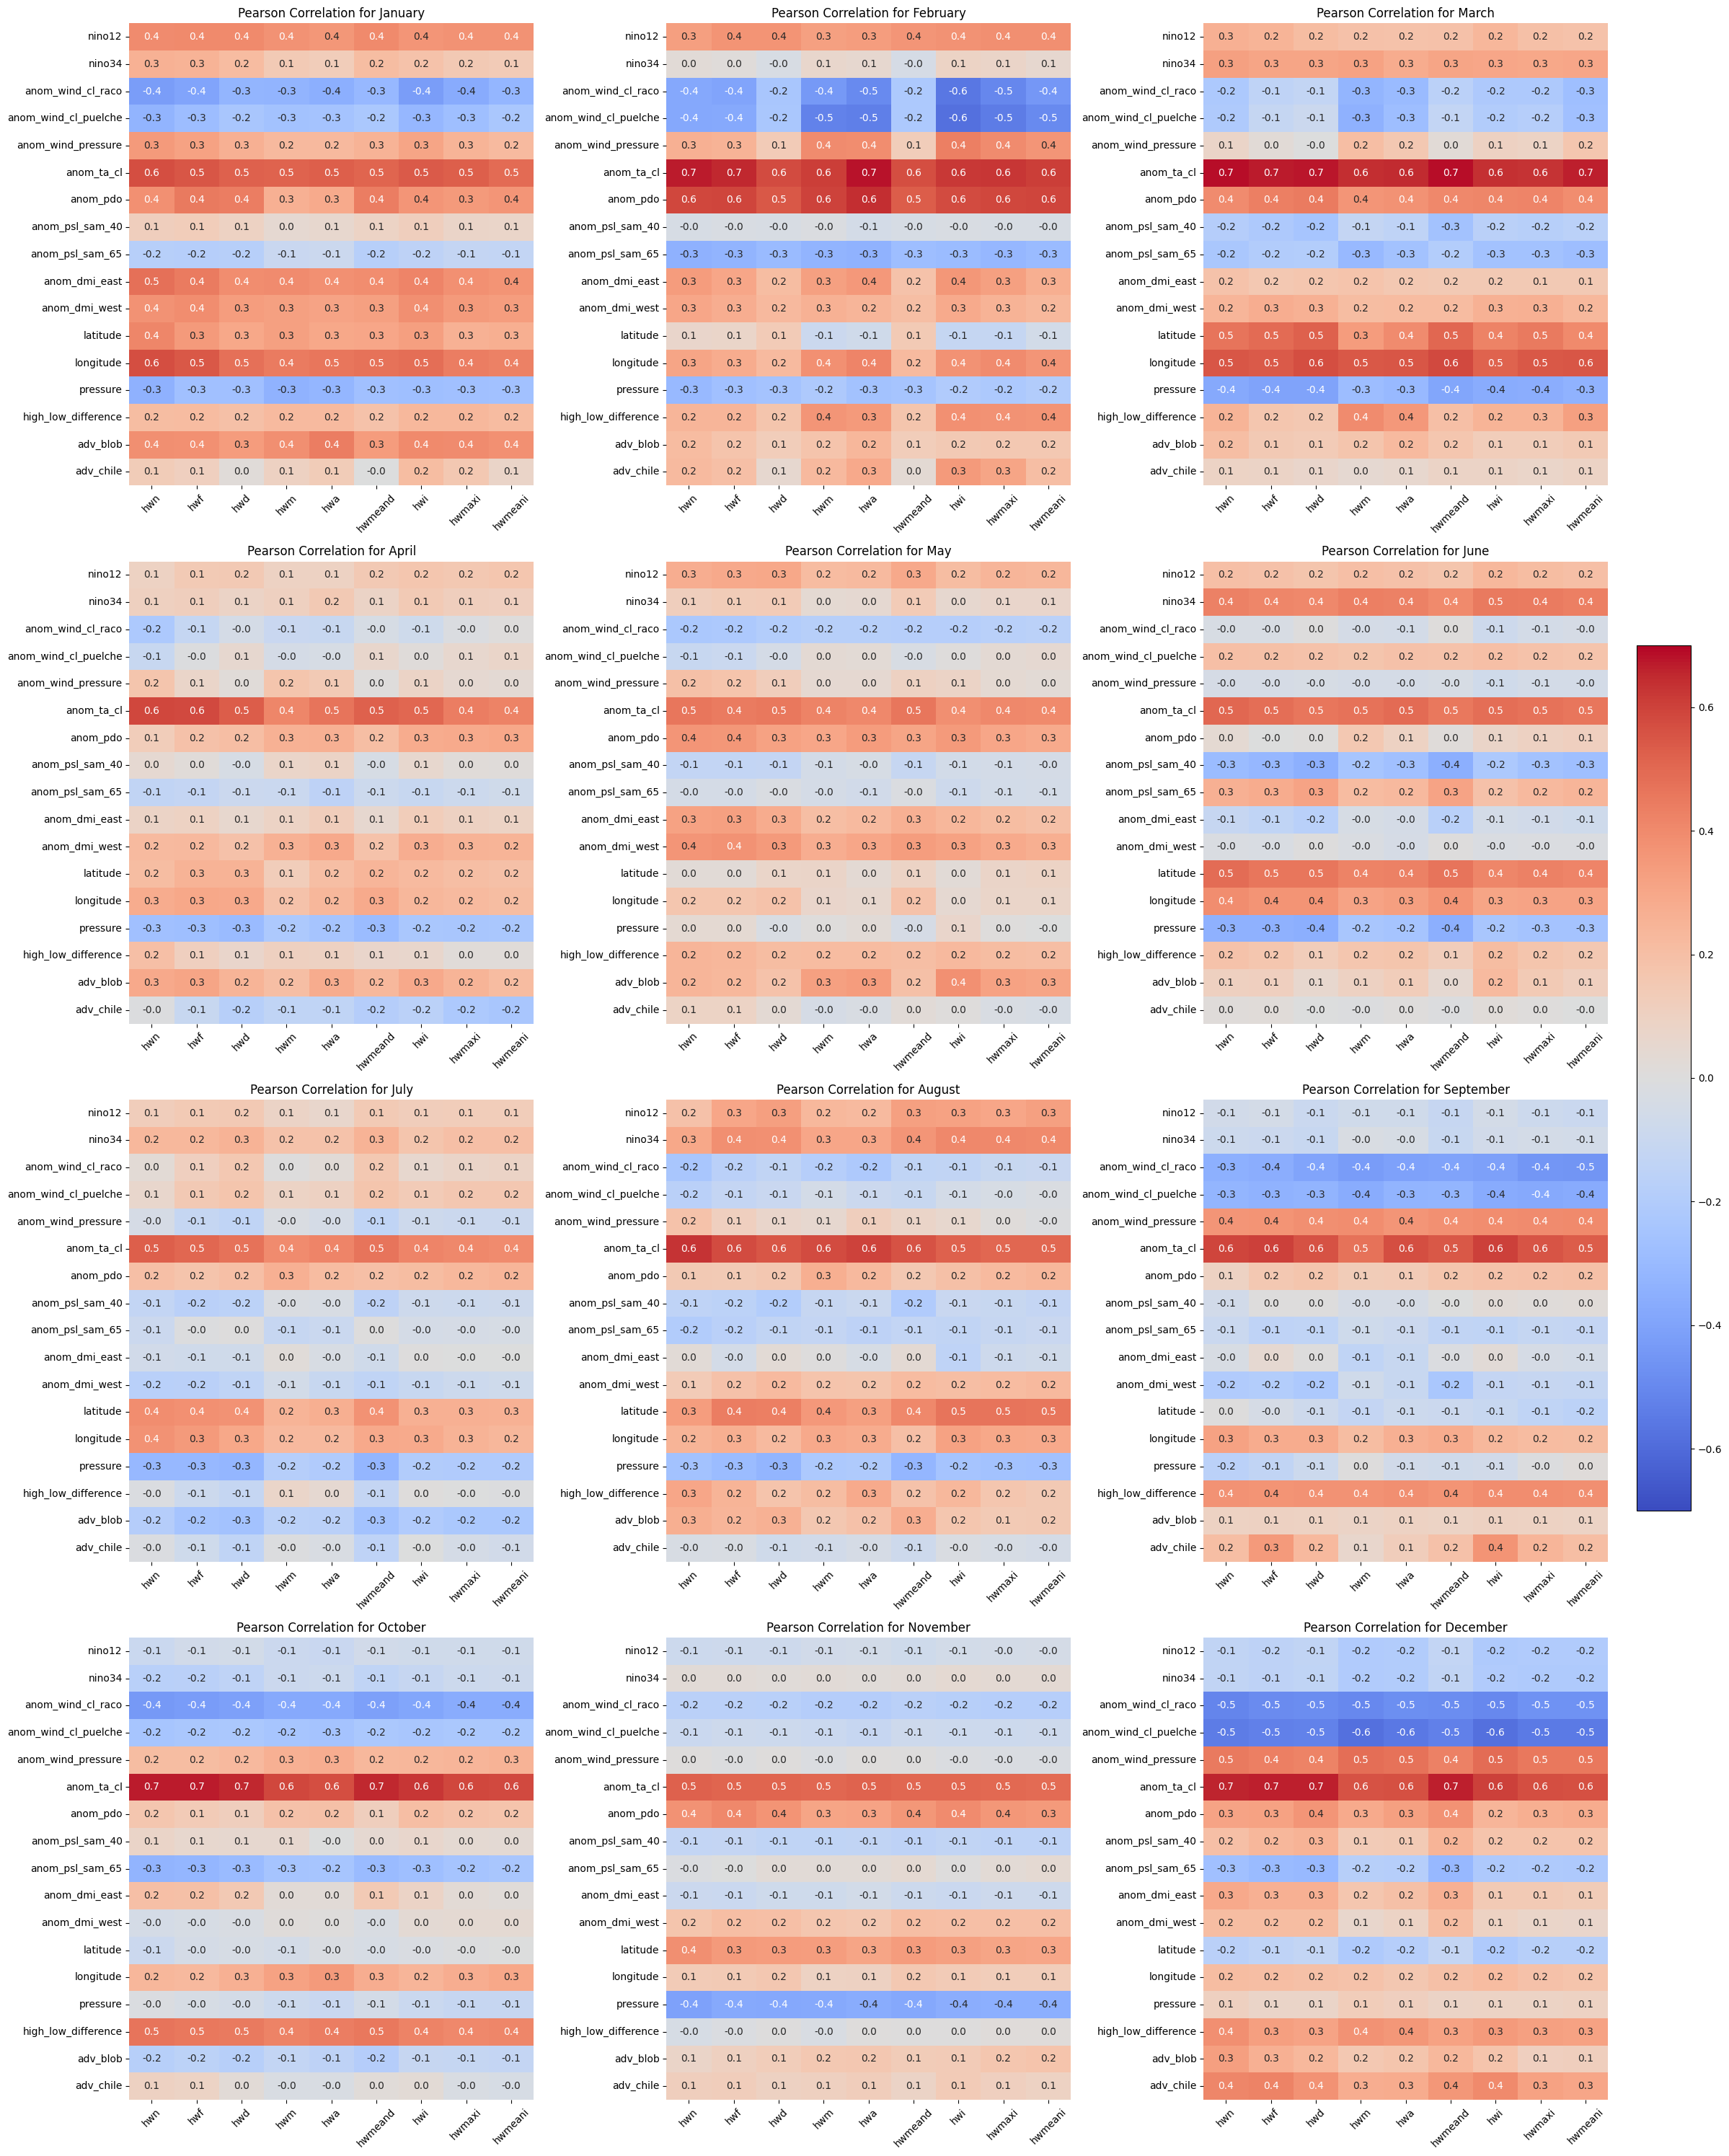

In [7]:
seasons = {
    1 : "January",
    2 : "February",
    3 : "March",
    4 : "April",
    5 : "May",
    6 : "June",
    7 : "July",
    8 : "August",
    9 : "September",
    10 : "October",
    11 : "November", 
    12 : "December"
}
fig, axs = plt.subplots(4, 3, figsize=(25,30))
for i in range(1,13):
    ax = axs.flatten()[i-1]
    # display(
    df = era5_df[era5_df.index.month==i].corr()[-9:].T[:-9]
    sns.heatmap(df, annot=True, cmap='coolwarm', ax=ax, vmin=-0.7, vmax=0.7, cbar=False,  fmt=".1f")
        # .style.set_caption("Correlation for ERA5")
        # .background_gradient(cmap="coolwarm")
        # .format("{:.2f}")
        # )
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_title(f"Pearson Correlation for {seasons[i]}")
cbar_ax = fig.add_axes([.91, .3, .03, .4])
fig.colorbar(ax.collections[0], cax=cbar_ax)
plt.subplots_adjust(right=0.88)
fig.tight_layout(rect=(0,0,0.9,1))